In [1]:
# Data from 
# Altman, Edward I., Brooks Brady, Andrea Resti and Andrea Sironi, 2003, “The Link
# between Default and Recovery Rates: Theory, Empirical Evidence and Implications”,
# NYU Salomon Center Working Paper Series # S-03-4, Journal of Business, November
# 2005, 78 (6), 2203-27. 

# https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1295806

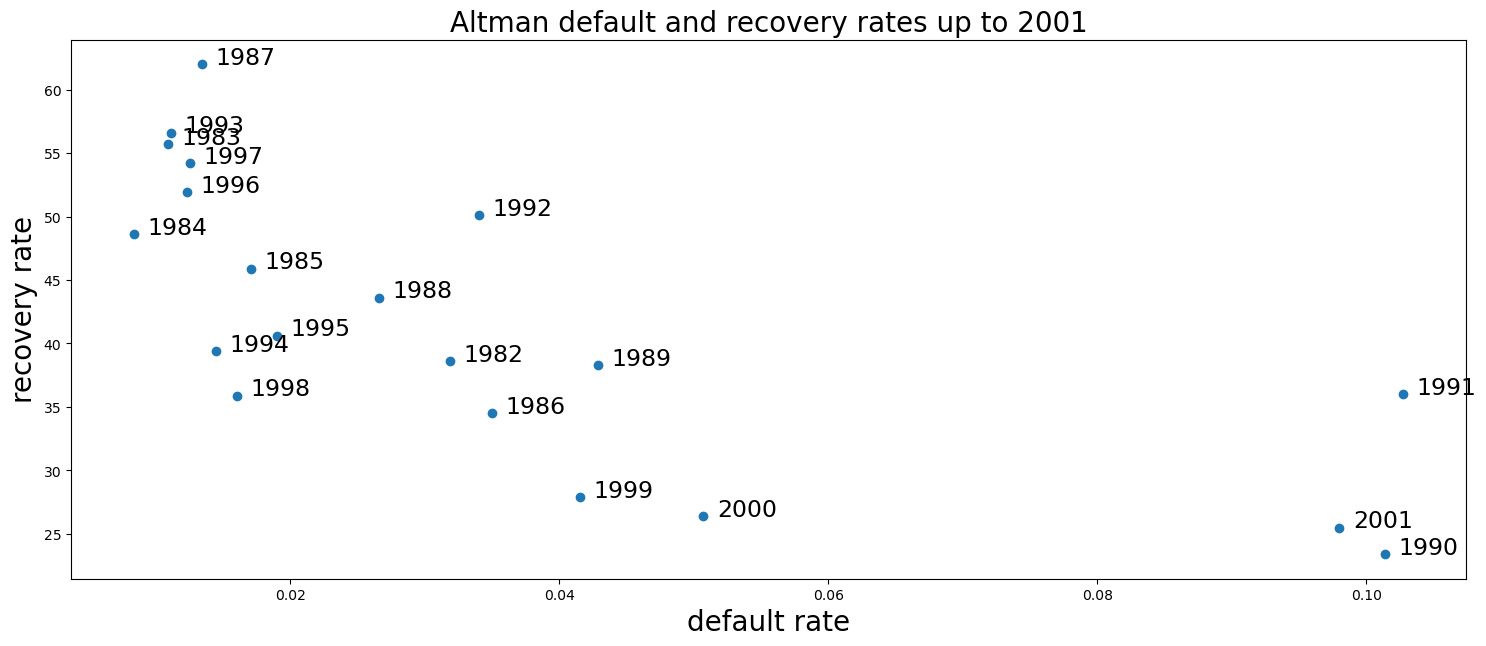

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

file_name = "Altman default and recovery rates.xlsx"
Altman = pd.read_excel(file_name, index_col='Year')
# display(Altman)

plt.figure(figsize=(18,7))
plt.scatter(Altman['Default_rate'], Altman['Recovery_rate'])
for y, (d,r) in zip(Altman.index, Altman.values):
    plt.text(d+.001,r,y,fontsize=17)
plt.title("Altman default and recovery rates up to 2001",fontsize=20)
plt.xlabel("default rate",fontsize=20)
plt.ylabel("recovery rate",fontsize=20)
plt.show()

In [3]:
np.corrcoef(Altman[['Default_rate','Recovery_rate']].transpose())

array([[ 1.        , -0.71682513],
       [-0.71682513,  1.        ]])

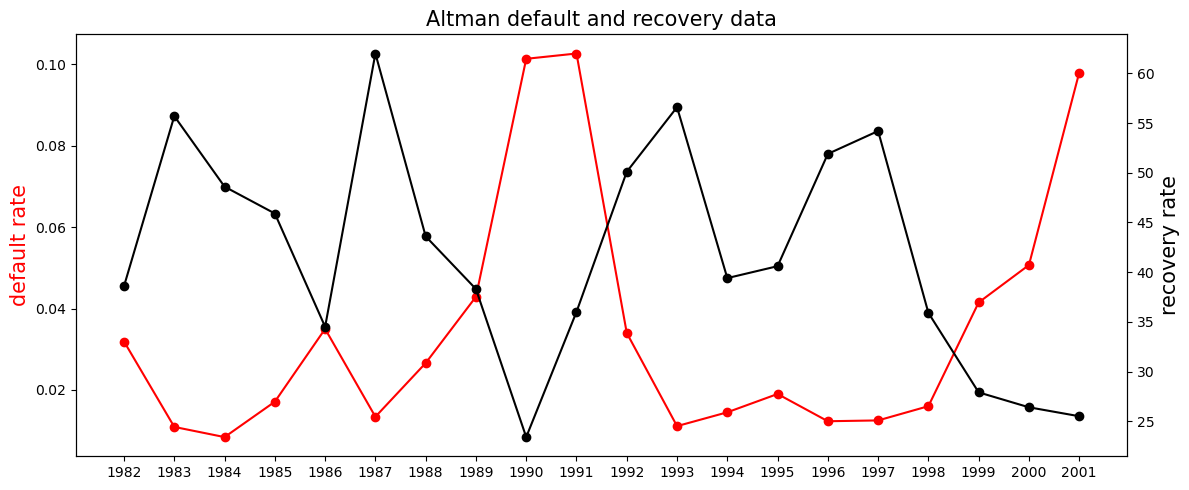

In [4]:
years = [int(x) for x in Altman.index]

fig, ax1 = plt.subplots(figsize=(12,5))

color = 'red'
plt.plot(years, Altman['Default_rate'], 'o-',color=color,label='default rate')
ax1.set_title("Altman default and recovery data",fontsize=15)
ax1.set_ylabel('default rate', color=color, fontsize=15)


ax2 = ax1.twinx()
color = 'black'
ax2.plot(years, Altman['Recovery_rate'], 'o-', color=color, label='recovery rate')
ax2.set_ylabel('recovery rate', color=color, fontsize=15)

fig.tight_layout()
plt.xticks(years)
plt.show()

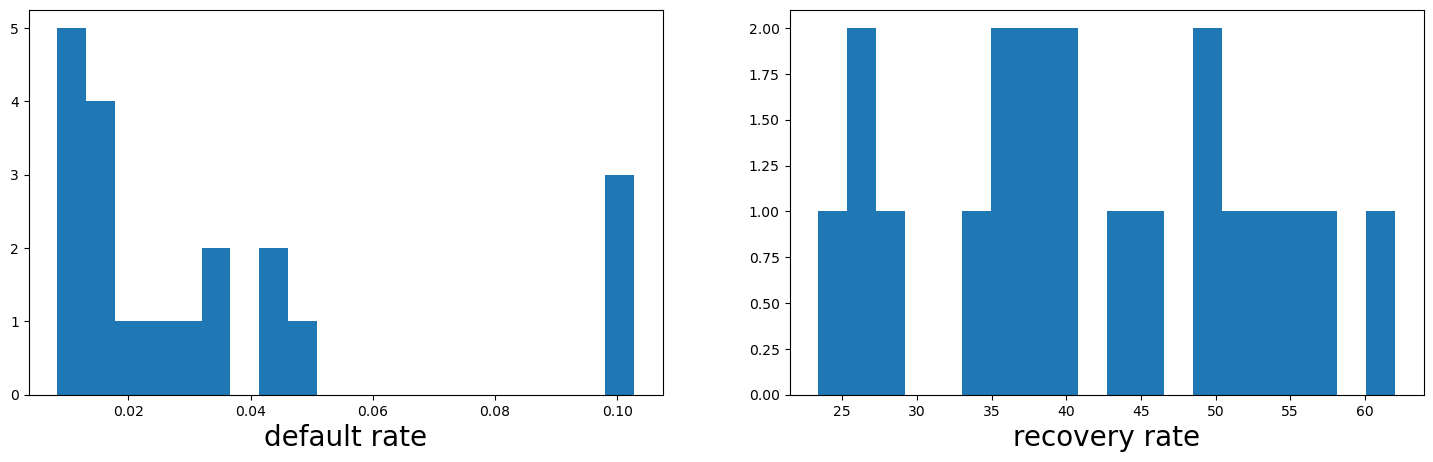

In [5]:
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.hist(Altman['Default_rate'],20)
plt.xlabel("default rate",fontsize=20)
plt.subplot(1,2,2)
plt.hist(Altman['Recovery_rate'],20)
plt.xlabel("recovery rate",fontsize=20)
plt.show()

# fit beta distributions to the marginal distributions
https://stats.stackexchange.com/questions/68983/beta-distribution-fitting-in-scipy

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html


In [6]:
from scipy.stats import beta
# beta.fit output α, β, loc (lower limit), scale (upper limit - lower limit)

dr_beta = beta.fit(Altman['Default_rate'])
rr_beta = beta.fit(Altman['Recovery_rate'])

print(dr_beta)
print(rr_beta)

C:\Users\ellio\.conda\envs\tf\lib\site-packages\scipy\stats\_continuous_distns.py:716: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


(0.30098852792459574, 0.478065766674896, -0.0006184831287185869, 0.1033184831287186)
(0.8719359570642605, 1.2890877204764364, 23.399999999999995, 40.07888312343822)


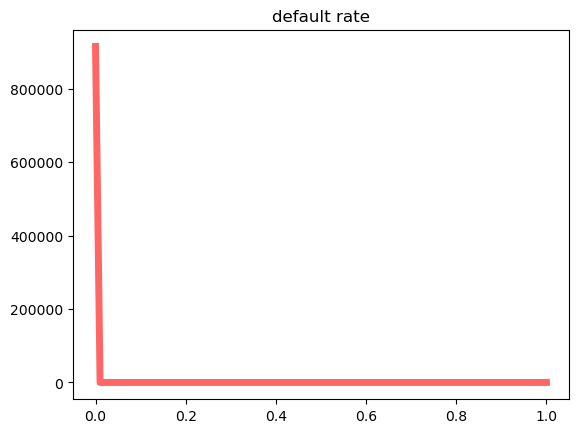

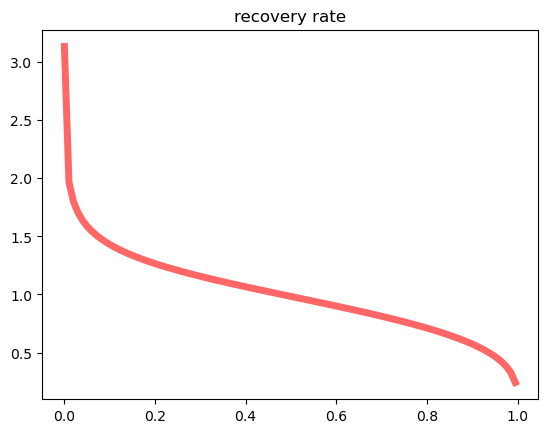

In [7]:

(a, b), title = dr_beta[:2], "default rate"
x = np.linspace(beta.ppf(0.001, a, b), beta.ppf(0.999, a, b), 100)
fig, ax = plt.subplots(1, 1)
ax.plot(x, beta.pdf(x, a, b), 'r-', lw=5, alpha=0.6, label='beta pdf')
plt.title(title)

(a, b), title = rr_beta[:2], "recovery rate"
x = np.linspace(beta.ppf(0.001, a, b), beta.ppf(0.999, a, b), 100)
fig, ax = plt.subplots(1,1)
ax.plot(x, beta.pdf(x, a, b), 'r-', lw=5, alpha=0.6, label='beta pdf')
plt.title(title)

plt.show()